<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/05-cereal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 180 Lab 5: Cereal Data

## Introduction:


Everyone loves cereal. But have you ever thought deeply about your cereal? Well now is your chance to take a data driven view of your breakfast.

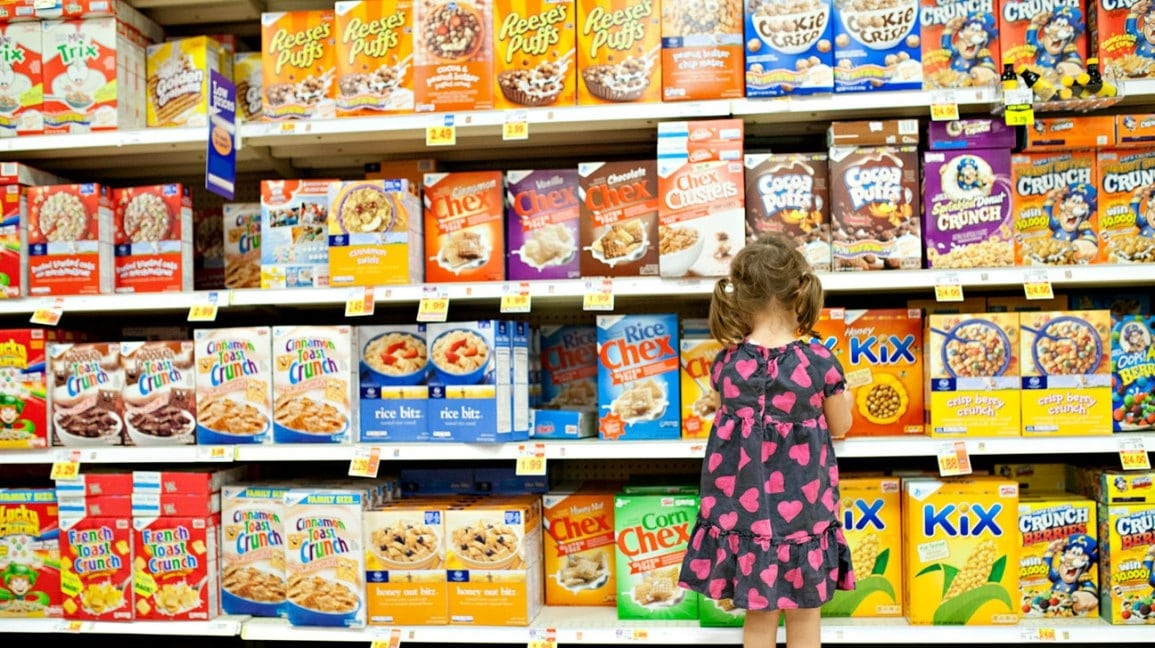


### Getting Started:
Download the data from github. Run the code below to download the data that you'll be using in this lab.

You may use pandas, numpy, matplotlib and/or seaborn for these excercises.

You can use/read their respective documentation in the links below (only if you need too, it's not required for the lab):

*   Seaborn [Documentation]("https://seaborn.pydata.org/tutorial.html")
*   Matplotlib [Documentation]("https://matplotlib.org/stable/api/index.html")
*   Numpy [Documentation]("https://numpy.org/doc/1.23/user/index.html#user")
*   Pandas [Documentation]("https://pandas.pydata.org/docs/user_guide/index.html#user-guide")







In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cereal = pd.read_csv('https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cereal.csv')

## Exercise 1: Protein Powder
Carbs, fats and proteins are the three primary macro nutrients. Create a figure plotting the distribution of each of these macro nutrients together (i.e., three distributions on a single plot). Make sure to provide a legend.

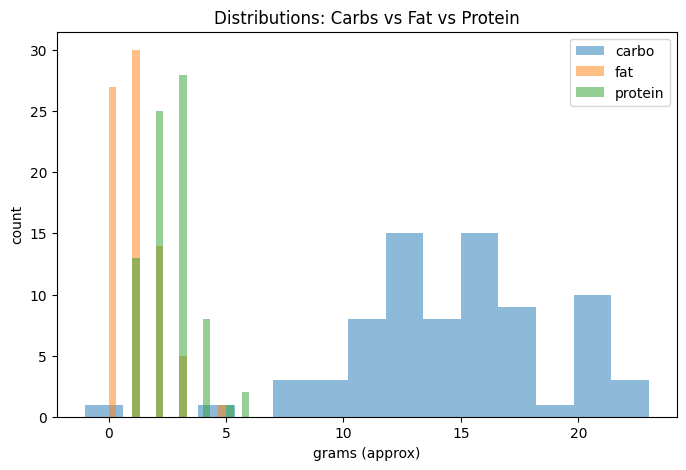

In [5]:
# Enter all of your code for exercise 1 here. Feel free to add more cells if you need to:
plt.figure(figsize=(8,5))

plt.hist(cereal["carbo"], bins=15, alpha=0.5, label="carbo")
plt.hist(cereal["fat"], bins=15, alpha=0.5, label="fat")
plt.hist(cereal["protein"], bins=15, alpha=0.5, label="protein")

plt.title("Distributions: Carbs vs Fat vs Protein")
plt.xlabel("grams (approx)")
plt.ylabel("count")
plt.legend()
plt.show()


## Exercise 2: Sugar Daddy
Get a list of the top 5 most sugary cereals and the 5 least sugary cereals.

In [6]:
# Enter all of your code for exercise 2 here. Feel free to add more cells if you need to:
top_5_sugary = cereal.sort_values("sugars", ascending=False).head(5)[["name", "sugars"]]
least_5_sugary = cereal.sort_values("sugars", ascending=True).head(5)[["name", "sugars"]]

top_5_sugary, least_5_sugary


(                     name  sugars
 30           Golden Crisp      15
 66                 Smacks      15
 52  Post Nat. Raisin Bran      14
 70      Total Raisin Bran      14
 6             Apple Jacks      14,
                          name  sugars
 57             Quaker Oatmeal      -1
 3   All-Bran with Extra Fiber       0
 55               Puffed Wheat       0
 20     Cream of Wheat (Quick)       0
 63             Shredded Wheat       0)

## Exercise 3: Cereal Killer
Get a list of the top 5 highest rated and lowest rated cereals.

In [7]:
# Enter all of your code for exercise 3 here. Feel free to add more cells if you need to:
top_5_rated = cereal.sort_values("rating", ascending=False).head(5)[["name", "rating"]]
low_5_rated = cereal.sort_values("rating", ascending=True).head(5)[["name", "rating"]]

top_5_rated, low_5_rated


(                         name     rating
 3   All-Bran with Extra Fiber  93.704912
 64     Shredded Wheat 'n'Bran  74.472949
 65  Shredded Wheat spoon size  72.801787
 0                   100% Bran  68.402973
 63             Shredded Wheat  68.235885,
                      name     rating
 10           Cap'n'Crunch  18.042851
 12  Cinnamon Toast Crunch  19.823573
 35       Honey Graham Ohs  21.871292
 18          Count Chocula  22.396513
 14            Cocoa Puffs  22.736446)

## Exercise 4: America
Quantify the relationship between sugar and ratings.

Make a plot to visualize this relationship. Superimpose a best fit line (with seaborn) to describe the relationship. It may be helpful to look at the [seaborn regplot documentation]("https://seaborn.pydata.org/generated/seaborn.regplot.html").

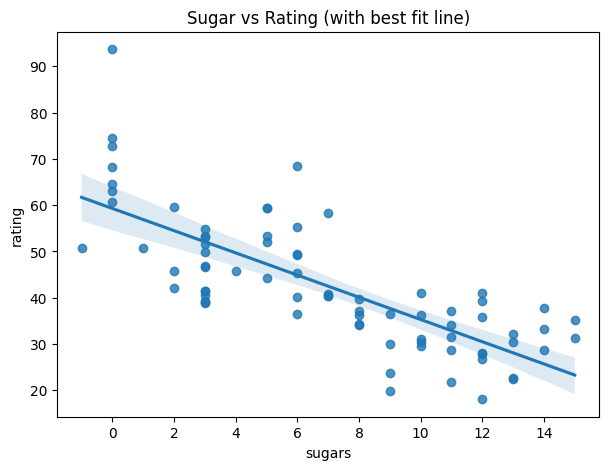

In [8]:
# Make the plot for the data visualization and line of best fit here:
plt.figure(figsize=(7,5))
sns.regplot(data=cereal, x="sugars", y="rating")
plt.title("Sugar vs Rating (with best fit line)")
plt.show()



Calculate a correlation statistic describing the relationship between sugar and ratings  (i.e., r or r squared).

In [9]:
# Calculate the statistic using this cell:
r = cereal["sugars"].corr(cereal["rating"])
r_squared = r**2

r, r_squared


(np.float64(-0.7596746584301076), np.float64(0.5771055866609007))

The scatter plot shows a clear negative relationship between sugars and rating.
As the amount of sugar increases, the cereal rating tends to decrease.
The best fit line slopes downward, which confirms this negative relationship.
This suggests that cereals with less sugar are generally rated higher.


(Write your statement here)


## Exercise 5: America Part 2
Make five plots comparing the relationships of carbo, sugars, calories, protein, and fat with rating.

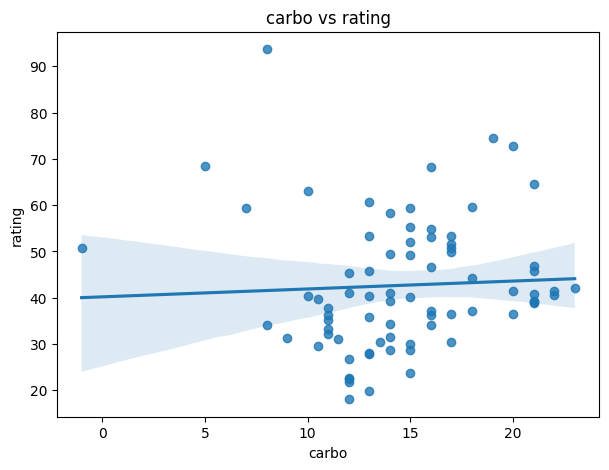

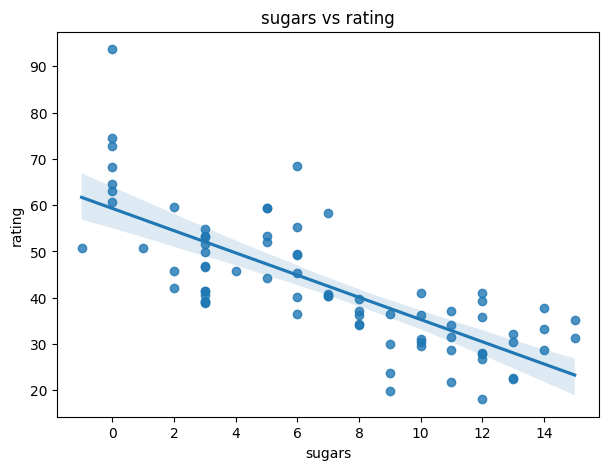

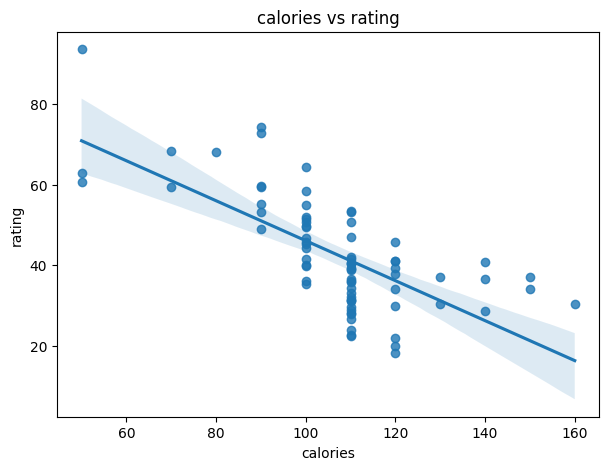

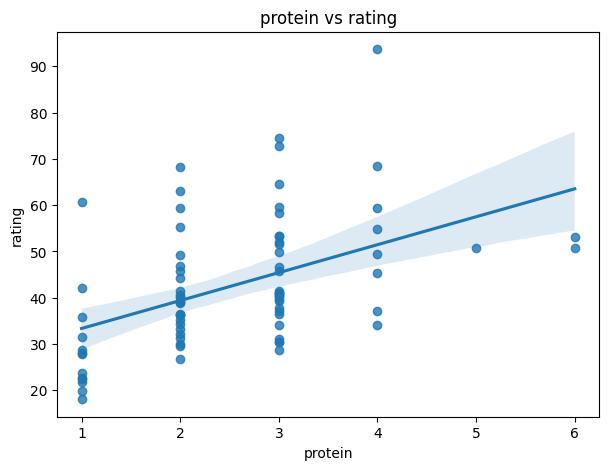

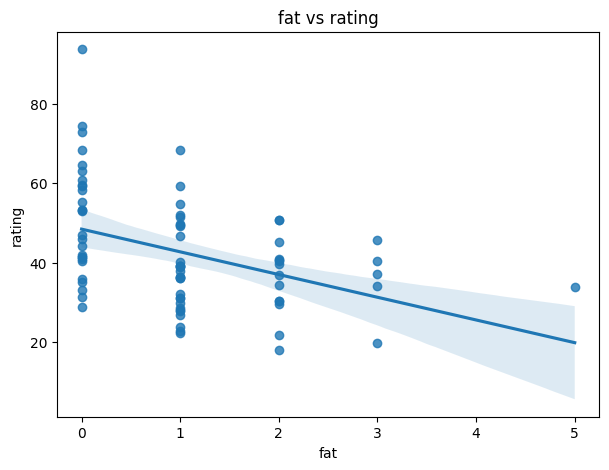

In [10]:
# Write your code to compare the various variables with rating below:
vars_to_compare = ["carbo", "sugars", "calories", "protein", "fat"]

for v in vars_to_compare:
    plt.figure(figsize=(7,5))
    sns.regplot(data=cereal, x=v, y="rating")
    plt.title(f"{v} vs rating")
    plt.show()


Of the variables carbo, sugars, calories, protein, and fat, which has the strongest relationship with rating? Justify your answer.

Among carbohydrates, sugars, calories, protein, and fat, sugars has the strongest relationship with rating. The plot shows the clearest downward trend, meaning higher sugar content is associated with lower ratings. The other variables show weaker or less consistent patterns.


## Exercise 6: Preparing for Mt. Everest
Do the same as you did with exercise 5, but instead compare carbo, sugars, protein, and fat with calories.

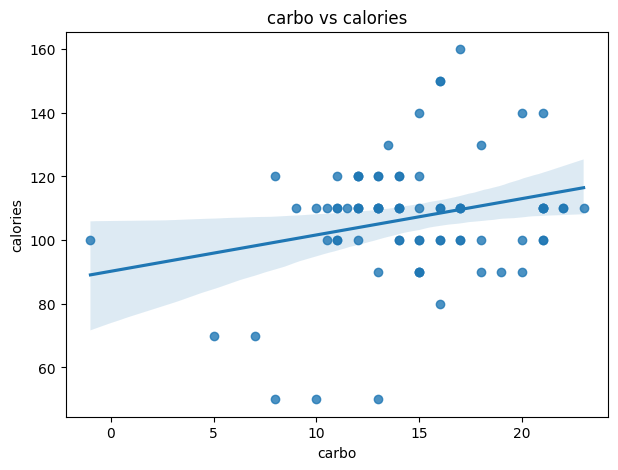

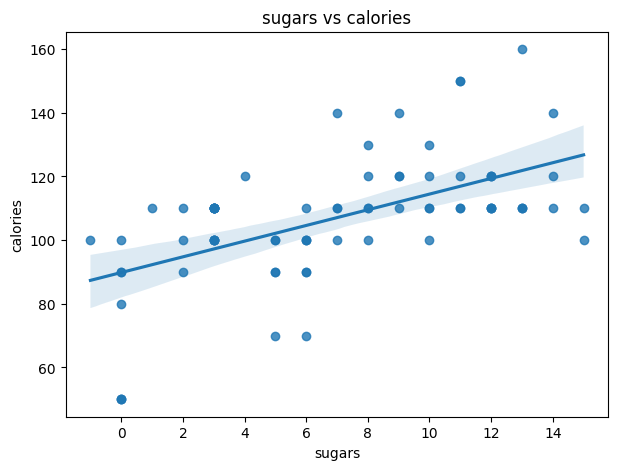

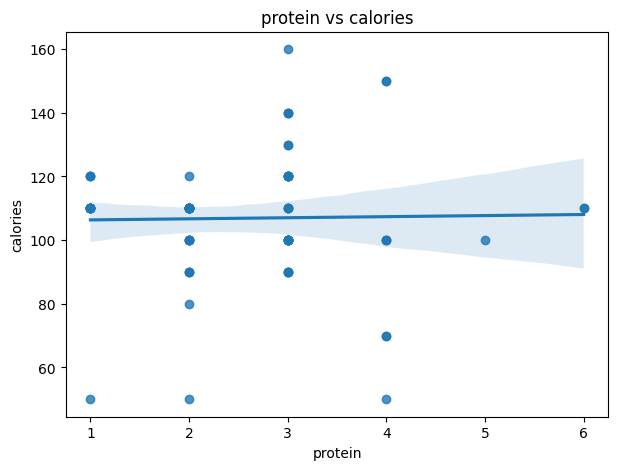

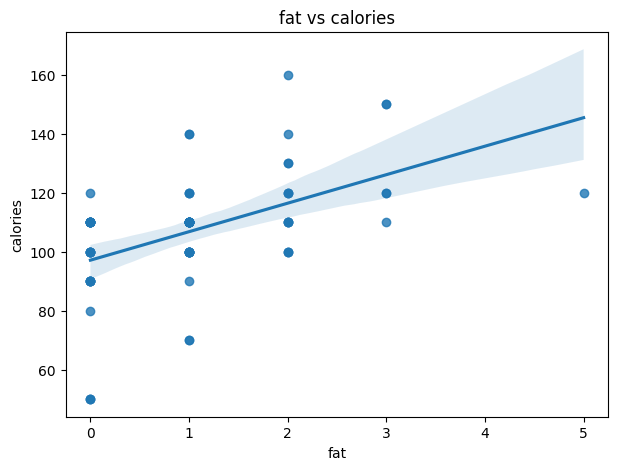

In [11]:
# Write your code to compare the various variables with calories below:
vars_cal = ["carbo", "sugars", "protein", "fat"]

for v in vars_cal:
    plt.figure(figsize=(7,5))
    sns.regplot(data=cereal, x=v, y="calories")
    plt.title(f"{v} vs calories")
    plt.show()


Of the variables carbo, sugars, protein, and fat, which has the strongest relationship with calories? Justify your answer.

Sugars has the strongest relationship with calories. The plot shows a clear positive trend, where cereals with more sugar tend to have more calories. Carbohydrates and fat also show some relationship, but sugars appears to be the strongest and most consistent.


## Exercise 7: It’s Hot and It's Cold
The type column has two values: H='hot' and C='cold'. What is the average rating of each type?

In [12]:
# Write your code to get the average rating by type of cereal below:
avg_rating_by_type = cereal.groupby("type")["rating"].mean()
avg_rating_by_type


,rating
type,
C,42.095218
H,56.737708


## Exercise 8: Captain Crunch the Numbers
Provide one additional insight from this dataset that you found interesting. Create at least one figure and explain why the figure was interesting to you.

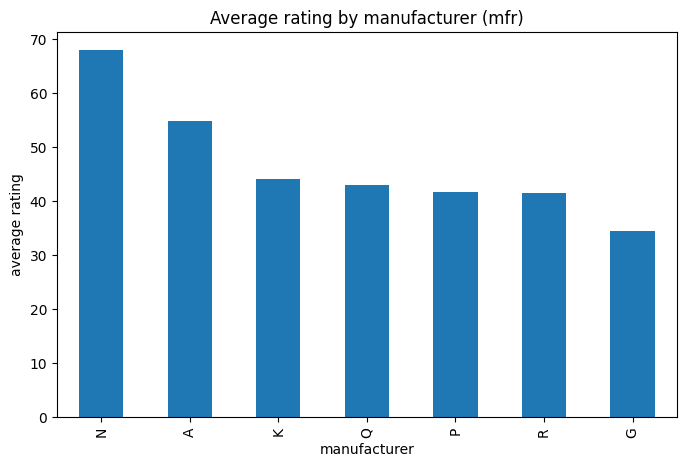

,rating
mfr,
N,67.968567
A,54.850917
K,44.038462
Q,42.915990
P,41.705744
R,41.542997
G,34.485852


In [13]:
# Create the extra plot below:
avg_rating_by_mfr = cereal.groupby("mfr")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_rating_by_mfr.plot(kind="bar")
plt.title("Average rating by manufacturer (mfr)")
plt.xlabel("manufacturer")
plt.ylabel("average rating")
plt.show()

avg_rating_by_mfr


This figure is interesting because it shows that average cereal ratings vary by
manufacturer. Some manufacturers consistently have higher average ratings than others.
This suggests that brand or manufacturing practices may play an important role in how cereals are perceived by consumers.
